Q1.Consider a dataset and train a Linear regression model using Batch Gradient descent,SGD,Mini batch(batch size=64)Gd and measure the execution time,no of parameter update ,final loss and based on your observation,identify the most suitable optimizer for large scale dataset

In [ ]:
import numpy as np
import time
from sklearn.datasets import load_diabetes

# Load dataset
data = load_diabetes()

X = data.data
y = data.target

# Add bias column
X = np.column_stack((np.ones(X.shape[0]), X))

print("Dataset : Diabetes")
print("Samples :", X.shape[0])
print("Features:", X.shape[1] - 1)
print()


# Loss function
def loss(X, y, theta):
    prediction = X @ theta
    return np.mean((prediction - y) ** 2)


# -------------------------------------------------
# Batch Gradient Descent
# -------------------------------------------------

def batch_gd(X, y):

    n, m = X.shape
    theta = np.zeros(m)

    lr = 0.1
    epochs = 1000
    updates = 0

    start = time.time()

    for epoch in range(epochs):

        prediction = X @ theta

        gradient = (X.T @ (prediction - y)) / n

        theta = theta - lr * gradient

        updates += 1

    end = time.time()

    return end - start, updates, loss(X, y, theta)


# -------------------------------------------------
# Stochastic Gradient Descent
# -------------------------------------------------

def sgd(X, y):

    n, m = X.shape
    theta = np.zeros(m)

    lr = 0.01
    epochs = 1000
    updates = 0

    start = time.time()

    for epoch in range(epochs):

        for i in range(n):

            prediction = X[i] @ theta

            gradient = (prediction - y[i]) * X[i]

            theta = theta - lr * gradient

            updates += 1

    end = time.time()

    return end - start, updates, loss(X, y, theta)


# -------------------------------------------------
# Mini-Batch Gradient Descent
# -------------------------------------------------

def mini_batch_gd(X, y):

    n, m = X.shape
    theta = np.zeros(m)

    lr = 0.05
    epochs = 1000
    batch_size = 64
    updates = 0

    start = time.time()

    for epoch in range(epochs):

        for i in range(0, n, batch_size):

            X_batch = X[i:i + batch_size]
            y_batch = y[i:i + batch_size]

            prediction = X_batch @ theta

            gradient = (
                X_batch.T @ (prediction - y_batch)
            ) / len(X_batch)

            theta = theta - lr * gradient

            updates += 1

    end = time.time()

    return end - start, updates, loss(X, y, theta)


# -------------------------------------------------
# Train all models
# -------------------------------------------------

batch = batch_gd(X, y)
stochastic = sgd(X, y)
mini = mini_batch_gd(X, y)


# -------------------------------------------------
# Display results
# -------------------------------------------------

print("-" * 60)
print("Optimizer\tTime(s)\tUpdates\t\tFinal Loss")
print("-" * 60)

print(
    f"Batch GD\t{batch[0]:.4f}\t"
    f"{batch[1]}\t\t{batch[2]:.2f}"
)

print(
    f"SGD\t\t{stochastic[0]:.4f}\t"
    f"{stochastic[1]}\t\t{stochastic[2]:.2f}"
)

print(
    f"Mini-Batch\t{mini[0]:.4f}\t"
    f"{mini[1]}\t\t{mini[2]:.2f}"
)

print("-" * 60)


# -------------------------------------------------
# Conclusion
# -------------------------------------------------

print("\nConclusion:")
print("Mini-Batch Gradient Descent is generally suitable")
print("for large-scale datasets because it provides a")
print("good balance between computation and convergence.")

Dataset : Diabetes
Samples : 442
Features: 10

------------------------------------------------------------
Optimizer	Time(s)	Updates		Final Loss
------------------------------------------------------------
Batch GD	0.0137	1000		3937.18
SGD		2.2587	442000		2879.48
Mini-Batch	0.0800	7000		3125.69
------------------------------------------------------------

Conclusion:
Mini-Batch Gradient Descent is generally suitable
for large-scale datasets because it provides a
good balance between computation and convergence.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 784)
Testing data shape : (10000, 784)

Training with: SGD
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.2709 - loss: 2.1411 - val_accuracy: 0.4457 - val_loss: 1.9496
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5478 - loss: 1.8193 - val_accuracy: 0.6532 - val_loss: 1.6439
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6786 - loss: 1.5477 - val_accuracy: 0.7468 - val_loss: 1.3844
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7375 - loss: 1.3244 - val_accuracy: 0.7943 - val_loss: 1.1777
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7696 - loss: 1.1511 - val_accuracy: 0.8185 - val_loss: 1.0200
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7903 - loss: 1.0200 - val_accuracy: 0.8352 - val_loss: 0.9010
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8050 - loss: 0.9205 - val_a

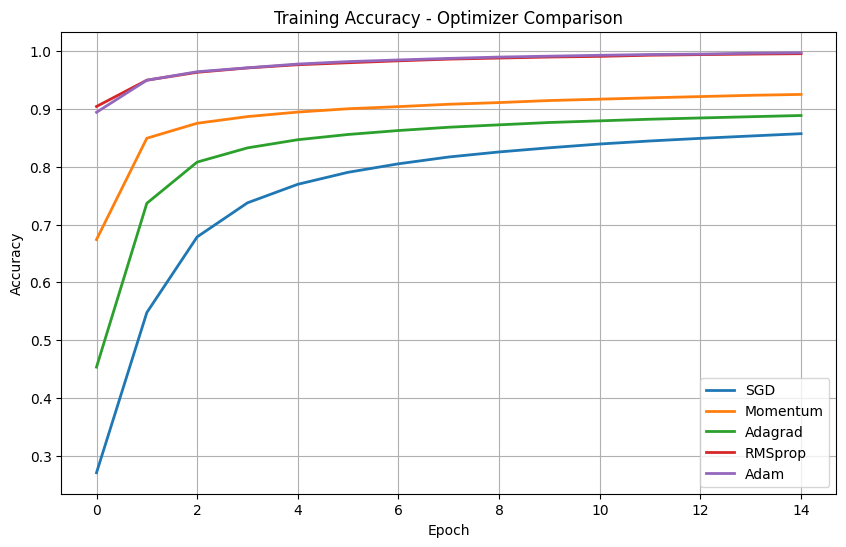

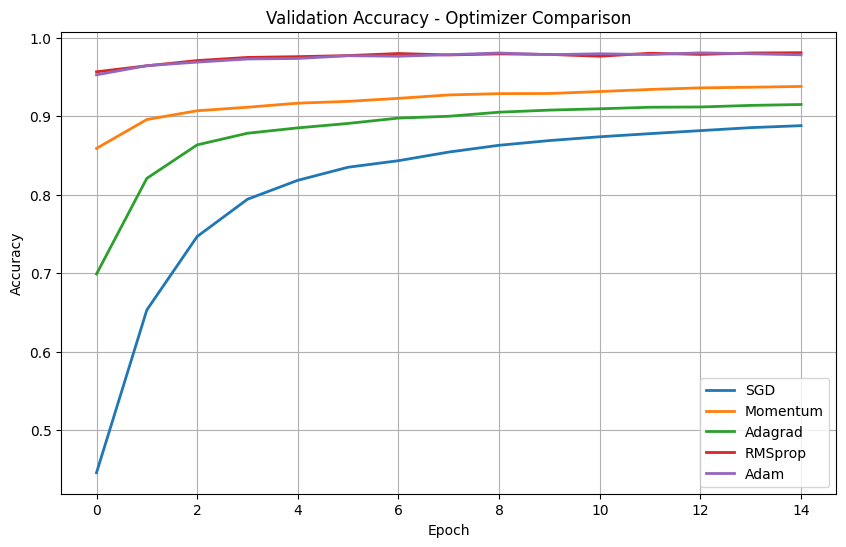

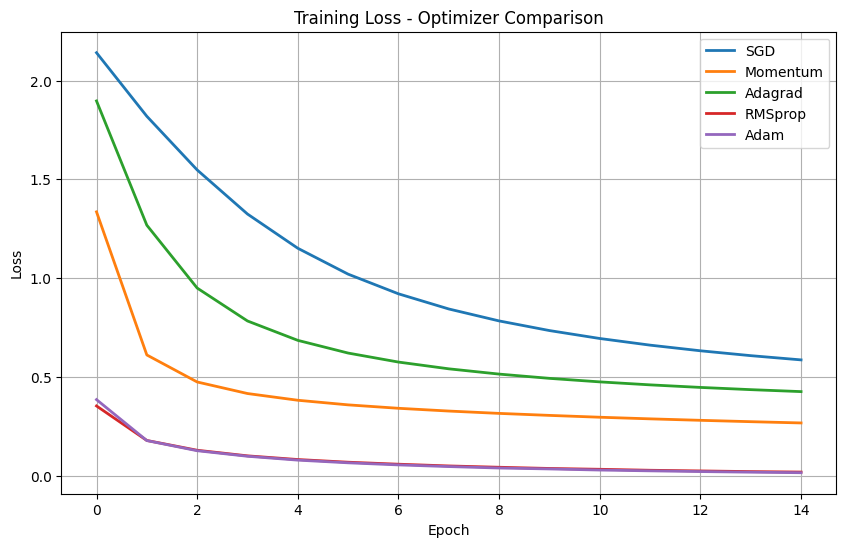

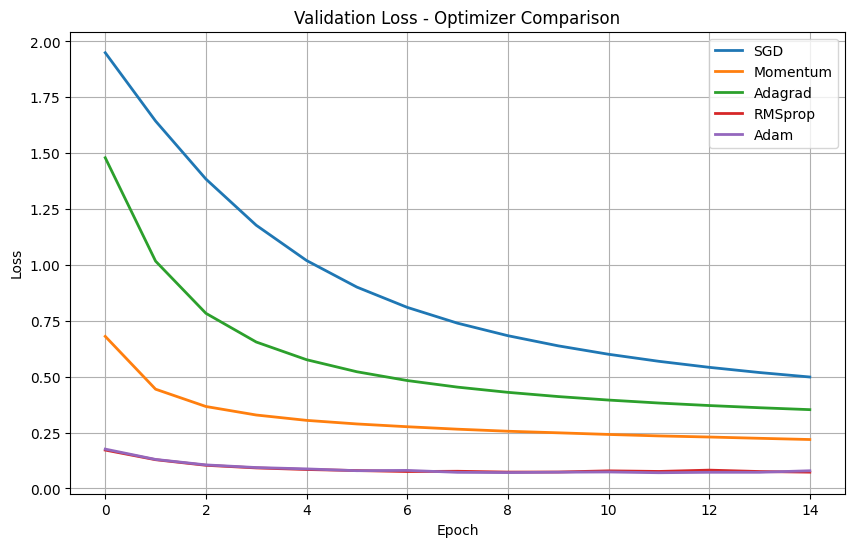

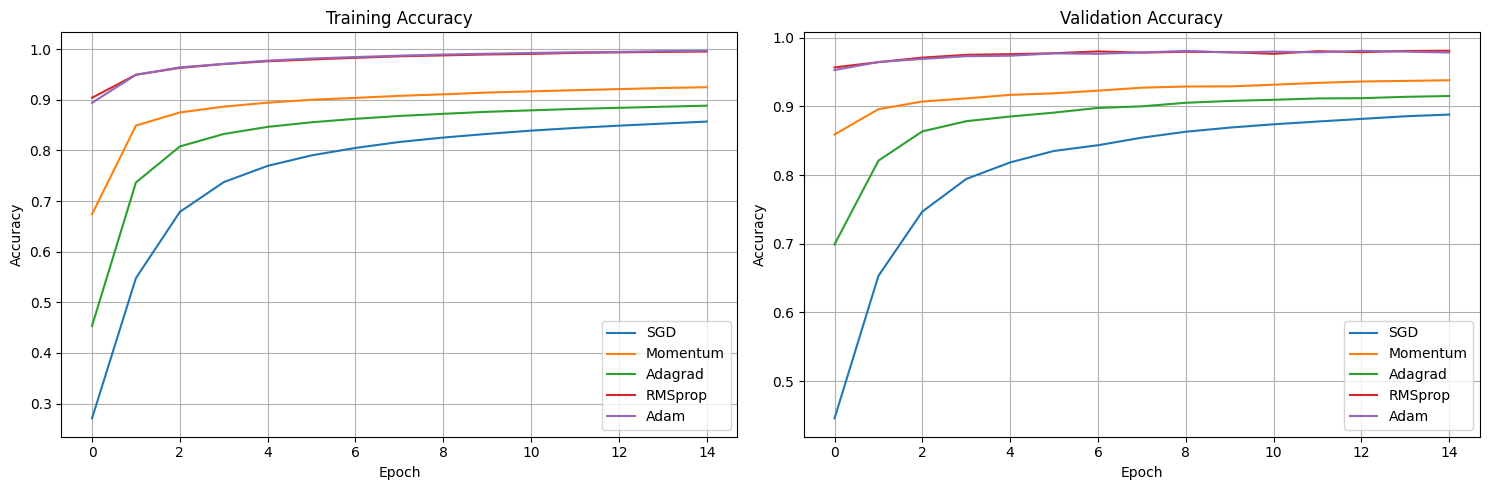

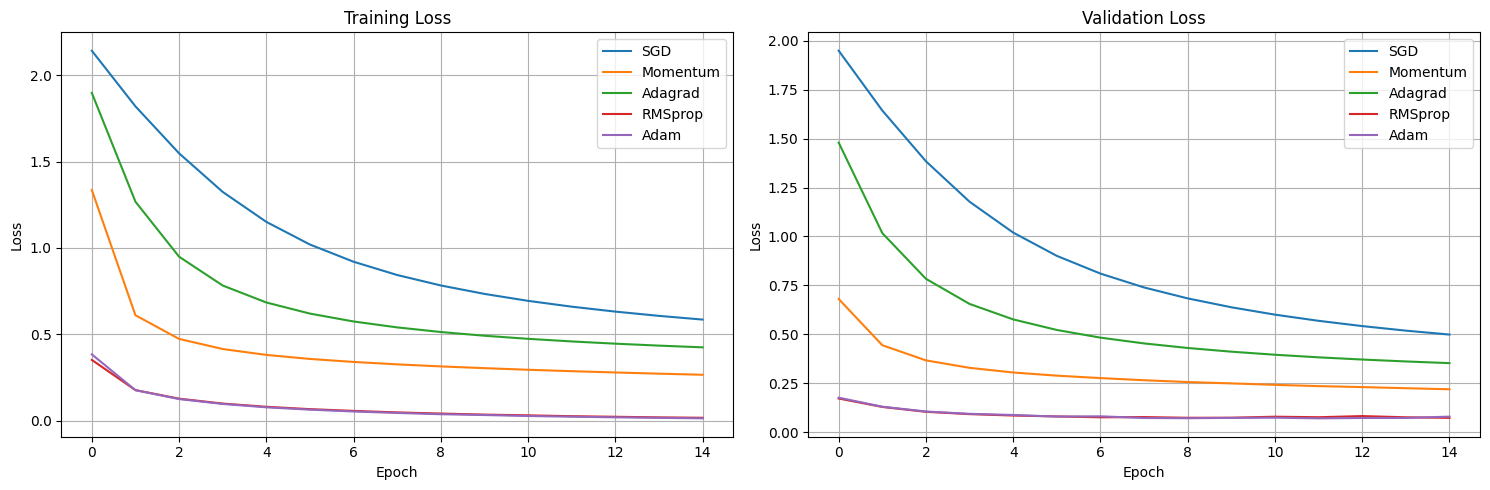


Test Results:
Optimizer  Test Loss  Test Accuracy
      SGD   0.543052         0.8722
 Momentum   0.251101         0.9263
  Adagrad   0.393657         0.8964
  RMSprop   0.069092         0.9791
     Adam   0.075883         0.9790

Epochs required to reach 95% validation accuracy:
SGD: Did not reach 95%
Momentum: Did not reach 95%
Adagrad: Did not reach 95%
RMSprop: Epoch 1
Adam: Epoch 1

Fastest-converging optimizer: RMSprop


In [ ]:
# Q2: MNIST - Comparison of SGD, Momentum, Adagrad, RMSprop and Adam

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# 1. Load MNIST dataset
# ---------------------------------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# ---------------------------------------------------------
# 2. Preprocess the data
# ---------------------------------------------------------
# Normalize pixel values from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

print("Training data shape:", x_train.shape)
print("Testing data shape :", x_test.shape)

# ---------------------------------------------------------
# 3. Create validation set
# ---------------------------------------------------------
# Use 10% of training data for validation
x_val = x_train[-6000:]
y_val = y_train[-6000:]

x_train_new = x_train[:-6000]
y_train_new = y_train[:-6000]

# ---------------------------------------------------------
# 4. Function to create the same model
# ---------------------------------------------------------
def create_model(optimizer):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ---------------------------------------------------------
# 5. Define optimizers
# ---------------------------------------------------------
# Same learning rate for all optimizers
learning_rate = 0.001

optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=learning_rate),

    "Momentum": tf.keras.optimizers.SGD(
        learning_rate=learning_rate,
        momentum=0.9
    ),

    "Adagrad": tf.keras.optimizers.Adagrad(
        learning_rate=learning_rate
    ),

    "RMSprop": tf.keras.optimizers.RMSprop(
        learning_rate=learning_rate
    ),

    "Adam": tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )
}


# ---------------------------------------------------------
# 6. Common training hyperparameters
# ---------------------------------------------------------
EPOCHS = 15
BATCH_SIZE = 128

histories = {}
models = {}

# ---------------------------------------------------------
# 7. Train the model using each optimizer
# ---------------------------------------------------------
for name, optimizer in optimizers.items():

    print("\n" + "=" * 50)
    print("Training with:", name)
    print("=" * 50)

    model = create_model(optimizer)

    history = model.fit(
        x_train_new,
        y_train_new,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    histories[name] = history
    models[name] = model


# ---------------------------------------------------------
# 8. Compare final Training and Validation Accuracy/Loss
# ---------------------------------------------------------
results = []

for name, history in histories.items():

    results.append({
        "Optimizer": name,
        "Training Accuracy": history.history["accuracy"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1],
        "Training Loss": history.history["loss"][-1],
        "Validation Loss": history.history["val_loss"][-1]
    })

results_df = pd.DataFrame(results)

print("\nFinal Results:")
print(results_df.to_string(index=False))

# ---------------------------------------------------------
# 9. Plot Training Accuracy
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["accuracy"],
        label=name,
        linewidth=2
    )

plt.title("Training Accuracy - Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 10. Plot Validation Accuracy
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=name,
        linewidth=2
    )

plt.title("Validation Accuracy - Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 11. Plot Training Loss
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["loss"],
        label=name,
        linewidth=2
    )

plt.title("Training Loss - Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 12. Plot Validation Loss
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["val_loss"],
        label=name,
        linewidth=2
    )

plt.title("Validation Loss - Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 13. Plot Accuracy comparison in one figure
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for name, history in histories.items():
    axes[0].plot(
        history.history["accuracy"],
        label=name
    )
    axes[1].plot(
        history.history["val_accuracy"],
        label=name
    )

axes[0].set_title("Training Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True)
axes[0].legend()

axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 14. Plot Loss comparison in one figure
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for name, history in histories.items():
    axes[0].plot(
        history.history["loss"],
        label=name
    )
    axes[1].plot(
        history.history["val_loss"],
        label=name
    )

axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 15. Evaluate all models on the test dataset
# ---------------------------------------------------------
test_results = []

for name, model in models.items():

    test_loss, test_accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    test_results.append({
        "Optimizer": name,
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy
    })

test_df = pd.DataFrame(test_results)

print("\nTest Results:")
print(test_df.to_string(index=False))


# ---------------------------------------------------------
# 16. Identify the fastest-converging optimizer
# ---------------------------------------------------------
# We use the epoch at which validation accuracy first reaches
# 95% as a simple convergence criterion.

threshold = 0.95

convergence_epochs = {}

for name, history in histories.items():

    val_accuracy = np.array(history.history["val_accuracy"])

    reached = np.where(val_accuracy >= threshold)[0]

    if len(reached) > 0:
        convergence_epochs[name] = reached[0] + 1
    else:
        convergence_epochs[name] = np.inf

print("\nEpochs required to reach 95% validation accuracy:")

for name, epoch in convergence_epochs.items():
    if epoch == np.inf:
        print(f"{name}: Did not reach 95%")
    else:
        print(f"{name}: Epoch {epoch}")

fastest_optimizer = min(
    convergence_epochs,
    key=convergence_epochs.get
)

print("\nFastest-converging optimizer:",
      fastest_optimizer)

Original shape: (60000, 28, 28)
Preprocessed shape: (60000, 28, 28, 1)
Minimum pixel value: -1.0
Maximum pixel value: 1.0


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)


Starting GAN training...

Epoch 01/30 | Generator Loss: 0.6741 | Discriminator Loss: 1.3113


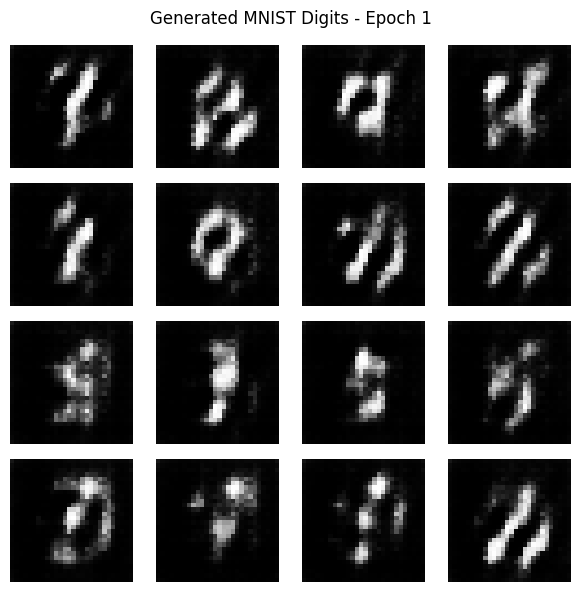

Epoch 02/30 | Generator Loss: 0.7317 | Discriminator Loss: 1.3534
Epoch 03/30 | Generator Loss: 0.7442 | Discriminator Loss: 1.3396
Epoch 04/30 | Generator Loss: 0.7675 | Discriminator Loss: 1.3233
Epoch 05/30 | Generator Loss: 0.7910 | Discriminator Loss: 1.2974


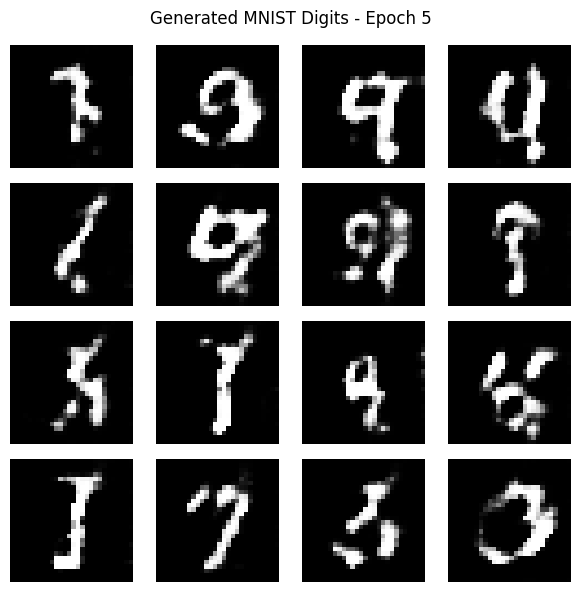

Epoch 06/30 | Generator Loss: 0.8344 | Discriminator Loss: 1.2625
Epoch 07/30 | Generator Loss: 0.8587 | Discriminator Loss: 1.2507
Epoch 08/30 | Generator Loss: 0.8313 | Discriminator Loss: 1.2798
Epoch 09/30 | Generator Loss: 0.8112 | Discriminator Loss: 1.2932
Epoch 10/30 | Generator Loss: 0.7856 | Discriminator Loss: 1.3158


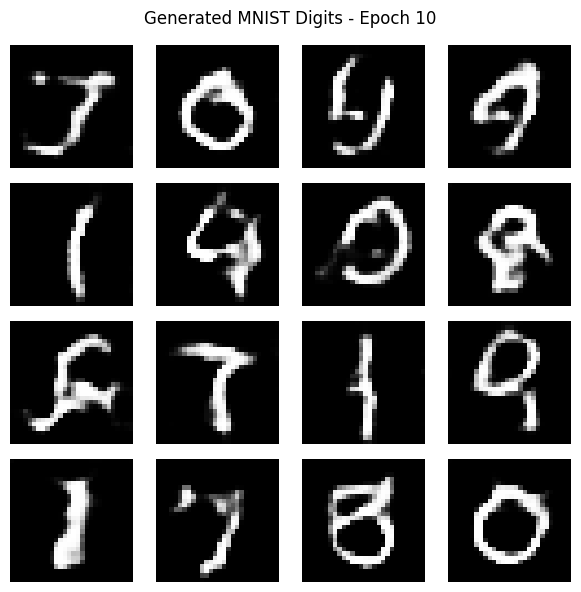

Epoch 11/30 | Generator Loss: 0.7938 | Discriminator Loss: 1.3149
Epoch 12/30 | Generator Loss: 0.7890 | Discriminator Loss: 1.3177
Epoch 13/30 | Generator Loss: 0.8053 | Discriminator Loss: 1.3093
Epoch 14/30 | Generator Loss: 0.7771 | Discriminator Loss: 1.3189
Epoch 15/30 | Generator Loss: 0.7852 | Discriminator Loss: 1.3224


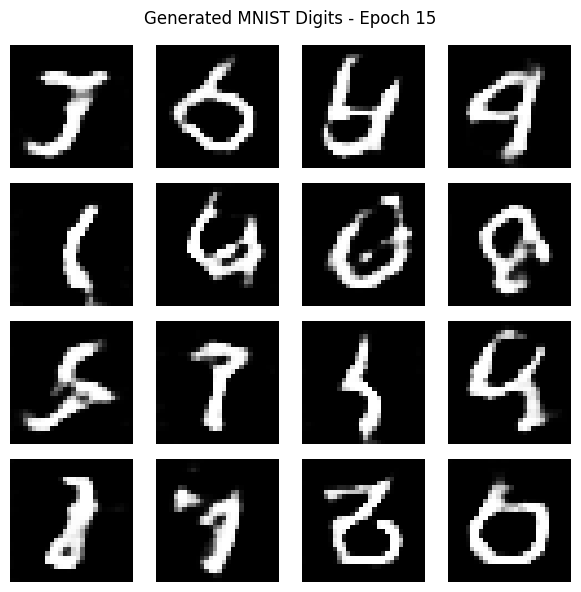

Epoch 16/30 | Generator Loss: 0.7924 | Discriminator Loss: 1.3115
Epoch 17/30 | Generator Loss: 0.8008 | Discriminator Loss: 1.3095
Epoch 18/30 | Generator Loss: 0.7953 | Discriminator Loss: 1.3144
Epoch 19/30 | Generator Loss: 0.7866 | Discriminator Loss: 1.3131
Epoch 20/30 | Generator Loss: 0.7901 | Discriminator Loss: 1.3119


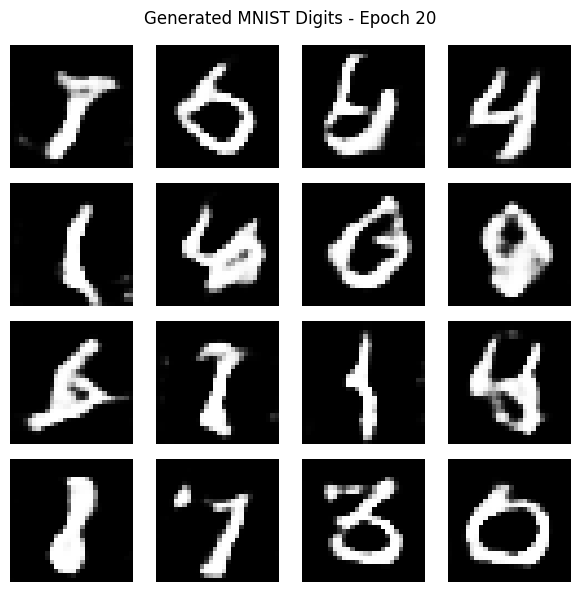

Epoch 21/30 | Generator Loss: 0.8136 | Discriminator Loss: 1.3045
Epoch 22/30 | Generator Loss: 0.8103 | Discriminator Loss: 1.3041
Epoch 23/30 | Generator Loss: 0.7936 | Discriminator Loss: 1.3048
Epoch 24/30 | Generator Loss: 0.8223 | Discriminator Loss: 1.3029
Epoch 25/30 | Generator Loss: 0.8163 | Discriminator Loss: 1.2993


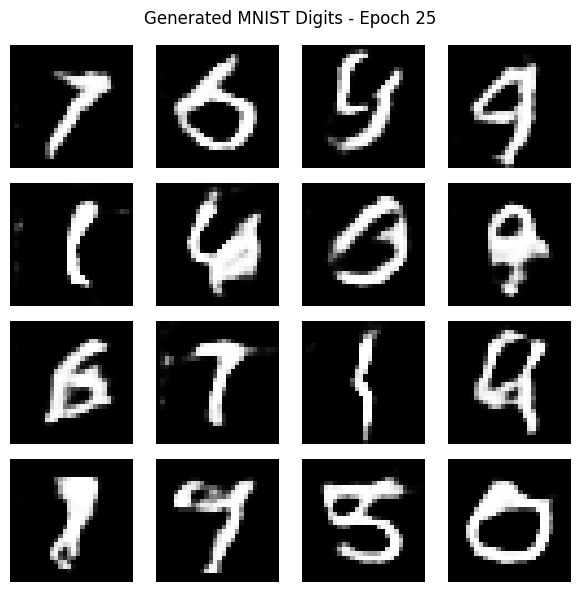

Epoch 26/30 | Generator Loss: 0.8001 | Discriminator Loss: 1.3038
Epoch 27/30 | Generator Loss: 0.7985 | Discriminator Loss: 1.3065
Epoch 28/30 | Generator Loss: 0.8323 | Discriminator Loss: 1.2964
Epoch 29/30 | Generator Loss: 0.8214 | Discriminator Loss: 1.2963
Epoch 30/30 | Generator Loss: 0.8129 | Discriminator Loss: 1.3042


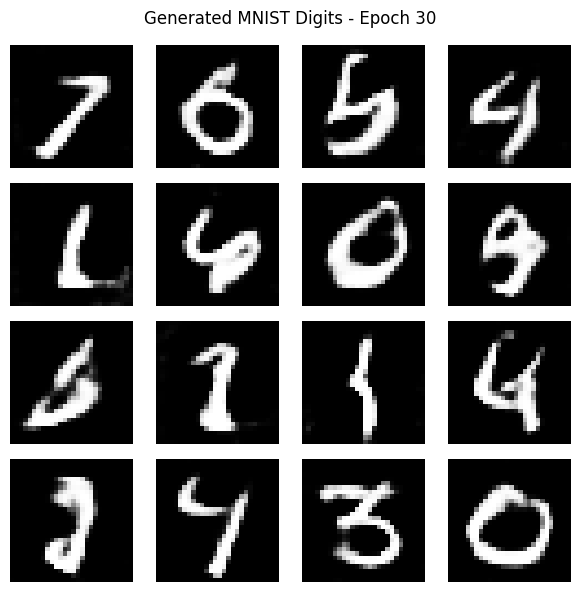

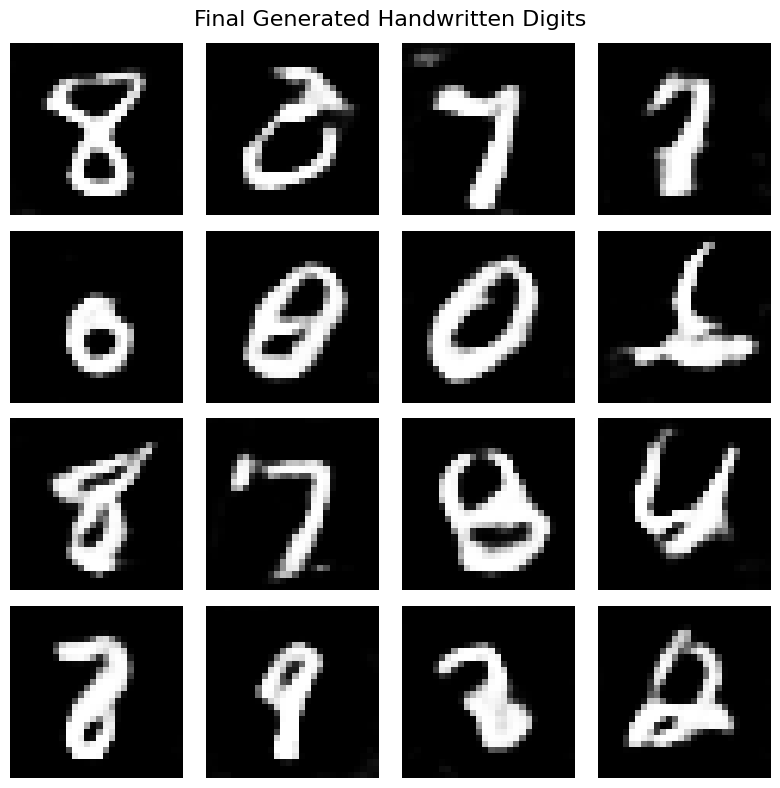

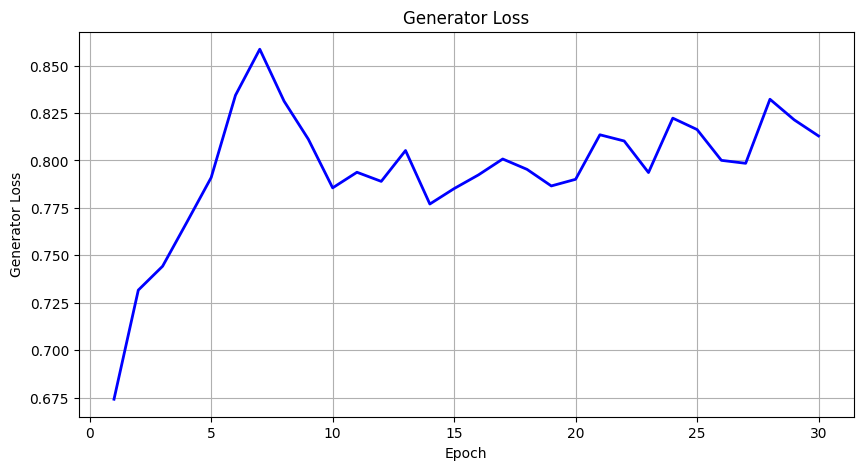

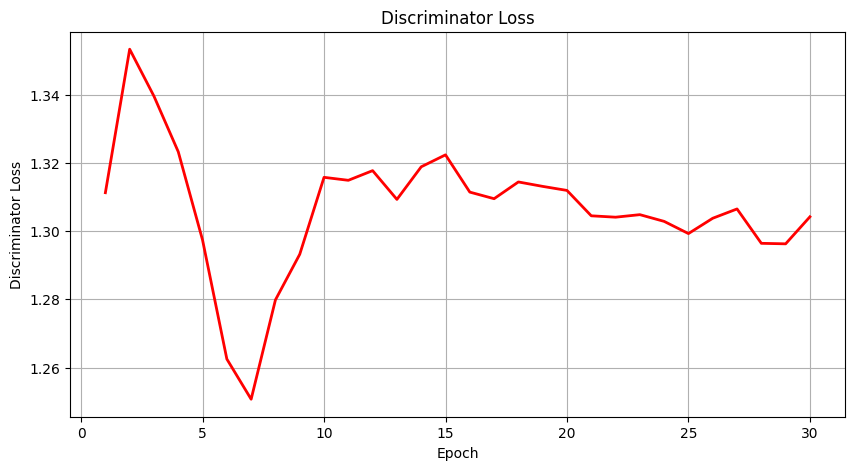

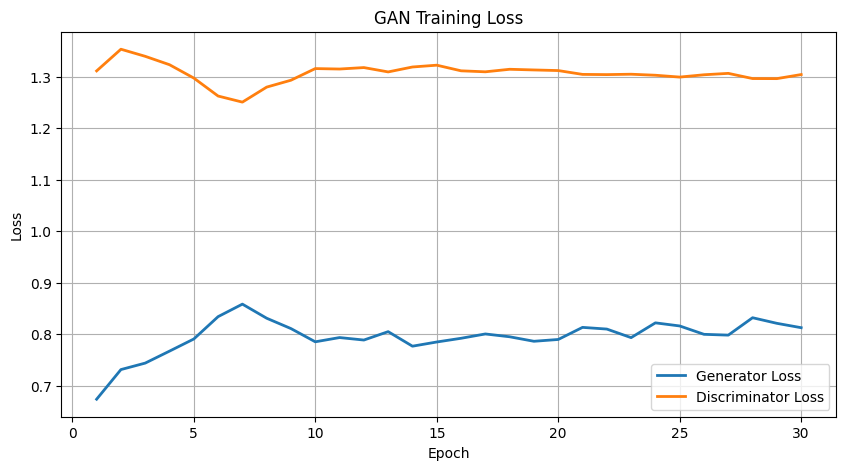


Final Training Losses
----------------------
Generator Loss     : 0.8129
Discriminator Loss  : 1.3042

Models saved successfully.
Generator    : mnist_generator.keras
Discriminator : mnist_discriminator.keras


In [ ]:
# ============================================================
# GAN on MNIST using TensorFlow / Keras
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# For reproducible results
tf.random.set_seed(42)
np.random.seed(42)


# ============================================================
# 1. Load and preprocess MNIST dataset
# ============================================================

(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

print("Original shape:", x_train.shape)

# Normalize images from [0, 255] to [-1, 1]
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# Add channel dimension: (60000, 28, 28) -> (60000, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)

print("Preprocessed shape:", x_train.shape)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())


# ============================================================
# 2. Create TensorFlow Dataset
# ============================================================

BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


# ============================================================
# 3. Design the Generator
# ============================================================

LATENT_DIM = 100

generator = tf.keras.Sequential([
    # Input: random noise vector of size 100
    tf.keras.layers.Input(shape=(LATENT_DIM,)),

    # 100 -> 7 x 7 x 256
    tf.keras.layers.Dense(7 * 7 * 256, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Reshape((7, 7, 256)),

    # 7x7x256 -> 14x14x128
    tf.keras.layers.Conv2DTranspose(
        128,
        kernel_size=5,
        strides=1,
        padding="same",
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    # 14x14x128 -> 14x14x64
    tf.keras.layers.Conv2DTranspose(
        64,
        kernel_size=5,
        strides=2,
        padding="same",
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    # 14x14x64 -> 28x28x1
    tf.keras.layers.Conv2DTranspose(
        1,
        kernel_size=5,
        strides=2,
        padding="same",
        activation="tanh"
    )
], name="Generator")


generator.summary()


# ============================================================
# 4. Design the Discriminator
# ============================================================

discriminator = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    # 28x28x1 -> 14x14x64
    tf.keras.layers.Conv2D(
        64,
        kernel_size=5,
        strides=2,
        padding="same"
    ),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    # 14x14x64 -> 7x7x128
    tf.keras.layers.Conv2D(
        128,
        kernel_size=5,
        strides=2,
        padding="same"
    ),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Flatten(),

    # Output: probability/logit for real or fake
    tf.keras.layers.Dense(1)
], name="Discriminator")


discriminator.summary()


# ============================================================
# 5. Define Loss Functions
# ============================================================

cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)


def discriminator_loss(real_output, fake_output):
    """
    Discriminator tries to classify:
    real images -> 1
    fake images -> 0
    """

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss


def generator_loss(fake_output):
    """
    Generator tries to make fake images
    appear real to the discriminator.
    """

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )


# ============================================================
# 6. Define Optimizers
# ============================================================

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)


# ============================================================
# 7. Training Parameters
# ============================================================

EPOCHS = 30

# Fixed random noise lets us see how generated images
# improve throughout training.
NUM_EXAMPLES = 16

seed = tf.random.normal(
    [NUM_EXAMPLES, LATENT_DIM]
)


# ============================================================
# 8. Training Step
# ============================================================

@tf.function
def train_step(images):

    # Generate random noise
    noise = tf.random.normal(
        [tf.shape(images)[0], LATENT_DIM]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        # Generate fake images
        generated_images = generator(
            noise,
            training=True
        )

        # Discriminator predictions
        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        # Calculate losses
        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    # Calculate gradients
    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update model weights
    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss


# ============================================================
# 9. Function to Generate Images
# ============================================================

def generate_and_display_images(model, epoch, test_input):

    predictions = model(
        test_input,
        training=False
    )

    fig = plt.figure(figsize=(6, 6))

    for i in range(predictions.shape[0]):

        plt.subplot(4, 4, i + 1)

        # Convert [-1, 1] back to [0, 1]
        image = (predictions[i, :, :, 0] + 1) / 2

        plt.imshow(
            image,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Generated MNIST Digits - Epoch {epoch}"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 10. Train the GAN
# ============================================================

generator_losses = []
discriminator_losses = []

print("\nStarting GAN training...\n")

for epoch in range(1, EPOCHS + 1):

    epoch_gen_loss = []
    epoch_disc_loss = []

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(
            image_batch
        )

        epoch_gen_loss.append(
            float(gen_loss)
        )

        epoch_disc_loss.append(
            float(disc_loss)
        )

    # Average losses for the epoch
    avg_gen_loss = np.mean(epoch_gen_loss)
    avg_disc_loss = np.mean(epoch_disc_loss)

    generator_losses.append(avg_gen_loss)
    discriminator_losses.append(avg_disc_loss)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"Discriminator Loss: {avg_disc_loss:.4f}"
    )

    # Display generated images every 5 epochs
    if epoch == 1 or epoch % 5 == 0:
        generate_and_display_images(
            generator,
            epoch,
            seed
        )


# ============================================================
# 11. Generate at least 16 final synthetic images
# ============================================================

final_images = generator(
    tf.random.normal([16, LATENT_DIM]),
    training=False
)

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    image = (final_images[i, :, :, 0] + 1) / 2

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Final Generated Handwritten Digits",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Plot Generator Loss
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, EPOCHS + 1),
    generator_losses,
    color="blue",
    linewidth=2
)

plt.title("Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Generator Loss")
plt.grid(True)

plt.show()


# ============================================================
# 13. Plot Discriminator Loss
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, EPOCHS + 1),
    discriminator_losses,
    color="red",
    linewidth=2
)

plt.title("Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Discriminator Loss")
plt.grid(True)

plt.show()


# ============================================================
# 14. Plot both losses together
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, EPOCHS + 1),
    generator_losses,
    label="Generator Loss",
    linewidth=2
)

plt.plot(
    range(1, EPOCHS + 1),
    discriminator_losses,
    label="Discriminator Loss",
    linewidth=2
)

plt.title("GAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 15. Display final loss values
# ============================================================

print("\nFinal Training Losses")
print("----------------------")
print(
    f"Generator Loss     : {generator_losses[-1]:.4f}"
)
print(
    f"Discriminator Loss  : {discriminator_losses[-1]:.4f}"
)


# ============================================================
# 16. Save trained models
# ============================================================

generator.save("mnist_generator.keras")
discriminator.save("mnist_discriminator.keras")

print("\nModels saved successfully.")
print("Generator    : mnist_generator.keras")
print("Discriminator : mnist_discriminator.keras")